In [77]:
%pip install numpy 
%pip install pandas 
%pip install scipy 
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, matplotlib.cm as cm
import soundfile as sf
import seaborn as sns
from scipy.io import wavfile
from scipy.signal import stft
from matplotlib import cm
from scipy.stats import entropy, gmean, kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding, MDS, SpectralEmbedding

# 1. Loading the files and creating a data frame

In [79]:
# - Durchsucht Unterordner Z01 und Z05 jeweils in deren Wav-Unterordner
pattern = os.path.join('*Datei', 'sig', 'Z*', 'Z*', 'Z*', 'Wav', '*.wav')

# Alle Dateien finden, die dem Muster entsprechen
files = glob.glob(pattern)
print(len(files), 'files', '\n', files[264])  # Print for Error-Checks

440 files 
 Seminaraufgabe_2_Datei\sig\Z03\Z03_Pos06_RC2_75k_0000\Z03_Pos06_RC2_75k_0000_1307031507\Wav\Z03_Pos06_RC2_75k_0000_1307031507_00000_14_Ch1.wav


In [80]:
data = []

# Durchläuft alle gefundenen Dateien
for fn in files:
    try:
        # fs = Abtastrate (Sampling Frequency)
        signal, fs = sf.read(fn)
    except Exception as e:
        # Print for Error
        print(f"Fehler beim Lesen von {fn}: {e}")
        continue  # Überspringt fehlerhafte Datei

    # Extrahiert Dateinamen
    basename = os.path.basename(fn)
    parts = basename.split('_')
    
    if len(parts) < 9:
        print("Unvollständiger Dateiname:", basename)
        continue  # Überspringen, wenn parts zu kurz ist

    sID = parts[8][:-4].strip()

    # Erstellt Datensatz mit Metadaten und Signal (Keys der Aufgabenstellung entsprechend)
    entry = {
        'fn': basename,         
        'sig': signal,     
        'spec': parts[0],  
        'mID': parts[4],   
        'time': parts[5],  
        'rID': parts[6],     
        'sID': parts[8][:-4],  
        'stft': None       
    }
    
    data.append(entry)  # Fügt Datensatz zur Liste hinzu

# Erstellt DataFrame aus der Liste
df = pd.DataFrame(data)
    
print(df['sID'].value_counts())


def compute_stft(sig, fs=1041667):
    f, t, Zxx = stft(sig, fs=fs, nperseg=1024)
    return (f, t, Zxx)

def analyze_signal(sig):
    signal_mean = np.mean(sig)
    signal_variance = np.var(sig)
    signal_skewness = skew(sig)
    signal_kurtosis = kurtosis(sig)
    signal_rms = np.sqrt(np.mean(sig**2))
    signal_peak = np.max(np.abs(sig))
    return signal_mean, signal_variance, signal_skewness, signal_rms, signal_peak, signal_kurtosis

def analyze_stft(stft_data):
    f, t, Zxx = stft_data
    magnitude = np.abs(Zxx)
    mag_mean = np.mean(magnitude, axis=1)
    spectral_mean = np.sum(f * mag_mean) / np.sum(mag_mean)
    spectral_variance = np.sum(((f - spectral_mean) ** 2) * mag_mean) / np.sum(mag_mean)

    upper_half = mag_mean[len(f)//2:]
    prob_dist = upper_half / np.sum(upper_half)
    entropy_upper = entropy(prob_dist)
    flatness = gmean(upper_half + 1e-8) / np.mean(upper_half)
    cumulative_energy = np.cumsum(mag_mean)
    rolloff_idx = np.searchsorted(cumulative_energy, 0.85 * cumulative_energy[-1])
    rolloff_freq = f[rolloff_idx]
    kurt_upper = kurtosis(upper_half)

    return spectral_mean, spectral_variance, entropy_upper, flatness, rolloff_freq, kurt_upper

def extract_all_features(sig, stft_data, suffix=''):
    sm, sv, ss, srms, sp, sk = analyze_signal(sig)
    spm, spv, se, sf, sr, skurt = analyze_stft(stft_data)

    return {
        f'sig_mean{suffix}': sm,
        f'sig_var{suffix}': sv,
        f'sig_skew{suffix}': ss,
        f'sig_rms{suffix}': srms,
        f'sig_peak{suffix}': sp,
        f'sig_kurtosis{suffix}': sk,
        f'spec_mean{suffix}': spm,
        f'spec_var{suffix}': spv,
        f'spec_entropy_up{suffix}': se,
        f'spec_flatness{suffix}': sf,
        f'spec_rolloff_freq{suffix}': sr,
        f'spec_kurtosis{suffix}': skurt
    }



sID
Ch1    220
Ch2    220
Name: count, dtype: int64


# 2. Separate channels

In [81]:
df['sID'] = df['sID'].astype(str).str.strip()
df_ch1 = df[df['sID'] == 'Ch1'].copy()
df_ch2 = df[df['sID'] == 'Ch2'].copy()
# print(df_ch1, df_ch2)

merge_keys = ['spec', 'mID', 'time', 'rID']

df_merged = pd.merge(
    df_ch1[['spec', 'mID', 'time', 'rID', 'sig']],
    df_ch2[['spec', 'mID', 'time', 'rID', 'sig']],
    on=merge_keys,
    suffixes=('_ch1', '_ch2')
)

# print("Gesamtbeispiele:", len(df_merged))
display(df_merged.head())
# print(df_ch2)

print("Ch1:", df_ch1[merge_keys].shape[0])
print("Ch2:", df_ch2[merge_keys].shape[0])
# print("df_merged", df_merged.columns)

,spec,mID,time,rID,sig_ch1,sig_ch2
0,Z01,0000,1307031427,00000,"[0.00048828125, 0.00244140625, 0.0029296875, 0...","[0.001953125, 0.0, 0.00146484375, 0.001953125,..."
1,Z01,0000,1307031427,00001,"[0.00146484375, 0.0, 0.00048828125, 0.00195312...","[-0.00048828125, 0.0009765625, 0.0, -0.0009765..."
2,Z01,0001,1312091511,00000,"[0.00048828125, 0.00146484375, 0.00048828125, ...","[0.00048828125, 0.0009765625, 0.001953125, 0.0..."
3,Z01,0001,1312091511,00001,"[0.00146484375, 0.0009765625, 0.0, 0.0, 0.0009...","[0.00048828125, 0.0, 0.0009765625, 0.000976562..."
4,Z01,0002,1312101402,00000,"[0.0, 0.00048828125, 0.0, -0.00048828125, 0.00...","[0.00048828125, -0.0009765625, 0.0, 0.00097656..."


Ch1: 220
Ch2: 220


# 3. Feature extraction

In [82]:
features = []

for idx, row in df_merged.iterrows():
    sig1 = row['sig_ch1']
    sig2 = row['sig_ch2']

    stft1 = compute_stft(sig1)
    stft2 = compute_stft(sig2)

    f1 = extract_all_features(sig1, stft1, suffix='_ch1')
    f2 = extract_all_features(sig2, stft2, suffix='_ch2')

    features.append({**row.to_dict(), **f1, **f2})

df_features = pd.DataFrame(features)
print("Признаки извлечены. Размерность:", df_features.shape)
display(df_features.head())


Признаки извлечены. Размерность: (392, 30)


,spec,mID,time,rID,sig_ch1,sig_ch2,sig_mean_ch1,sig_var_ch1,sig_skew_ch1,sig_rms_ch1,...,sig_skew_ch2,sig_rms_ch2,sig_peak_ch2,sig_kurtosis_ch2,spec_mean_ch2,spec_var_ch2,spec_entropy_up_ch2,spec_flatness_ch2,spec_rolloff_freq_ch2,spec_kurtosis_ch2
0,Z01,0000,1307031427,00000,"[0.00048828125, 0.00244140625, 0.0029296875, 0...","[0.001953125, 0.0, 0.00146484375, 0.001953125,...",0.001518,0.000824,-0.020609,0.028749,...,-0.173273,0.039612,0.457214,16.392937,57570.166639,9.592240e+09,5.217694,0.815069,59000.669922,77.143177
1,Z01,0000,1307031427,00001,"[0.00146484375, 0.0, 0.00048828125, 0.00195312...","[-0.00048828125, 0.0009765625, 0.0, -0.0009765...",0.001247,0.000837,0.003026,0.028963,...,-0.145501,0.040230,0.465515,16.315769,54821.522639,8.804397e+09,5.252934,0.852287,57983.416992,100.542796
2,Z01,0001,1312091511,00000,"[0.00048828125, 0.00146484375, 0.00048828125, ...","[0.00048828125, 0.0009765625, 0.001953125, 0.0...",0.000970,0.000561,0.035185,0.023708,...,-0.125625,0.033959,0.398102,18.489491,57202.157464,9.179451e+09,5.376821,0.918173,62052.428711,124.740067
3,Z01,0001,1312091511,00001,"[0.00146484375, 0.0009765625, 0.0, 0.0, 0.0009...","[0.00048828125, 0.0, 0.0009765625, 0.000976562...",0.000843,0.000567,0.026321,0.023826,...,-0.140516,0.034761,0.404480,18.523465,57238.206669,9.178731e+09,5.380707,0.917318,61035.175781,123.687647
4,Z01,0002,1312101402,00000,"[0.0, 0.00048828125, 0.0, -0.00048828125, 0.00...","[0.00048828125, -0.0009765625, 0.0, 0.00097656...",0.000748,0.000657,-0.003974,0.025645,...,-0.142080,0.040355,0.509003,20.519258,52919.188720,7.915353e+09,5.304285,0.890652,56966.164062,125.968764


In [83]:
featureslist = ['sig_mean', 'sig_var', 'sig_skew', 'sig_rms', 'sig_peak', 'sig_kurtosis' 'spec_mean', 'spec_var', 'spec_entropy_up', 'spec_flatness', 'spec_rolloff_freq', 'spec_kurtosis']  # added new features
for i in featureslist:
    df[i] = None

In [84]:
df_ch1_features = df_features[[col for col in df_features.columns if col.endswith('_ch1')]].copy()
df_ch2_features = df_features[[col for col in df_features.columns if col.endswith('_ch2')]].copy()

df_ch1_features['spec'] = df_features['spec']
df_ch2_features['spec'] = df_features['spec']

print(df_ch2_features)



                                               sig_ch2  sig_mean_ch2  \
0    [0.001953125, 0.0, 0.00146484375, 0.001953125,...      0.001020   
1    [-0.00048828125, 0.0009765625, 0.0, -0.0009765...      0.000738   
2    [0.00048828125, 0.0009765625, 0.001953125, 0.0...      0.001135   
3    [0.00048828125, 0.0, 0.0009765625, 0.000976562...      0.000993   
4    [0.00048828125, -0.0009765625, 0.0, 0.00097656...      0.000368   
..                                                 ...           ...   
387  [0.0009765625, -0.0009765625, 0.0, 0.001464843...      0.000891   
388  [0.00244140625, 0.00048828125, 0.00048828125, ...      0.001165   
389  [0.0, 0.00244140625, 0.00146484375, 0.00097656...      0.001310   
390  [0.00048828125, -0.00048828125, 0.0009765625, ...      0.000501   
391  [0.0009765625, 0.00048828125, 0.001953125, 0.0...      0.000932   

     sig_var_ch2  sig_skew_ch2  sig_rms_ch2  sig_peak_ch2  sig_kurtosis_ch2  \
0       0.001568     -0.173273     0.039612      0.45721

# 4. Feature Overview

## 4.1 Boxplot: comparison of characteristics between channels

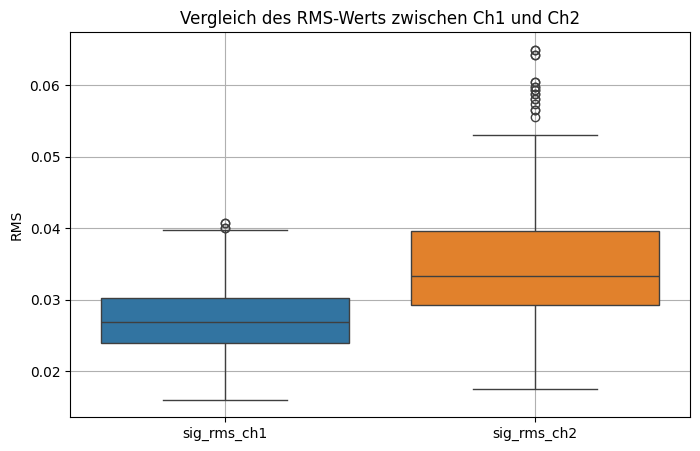

In [85]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_features[['sig_rms_ch1', 'sig_rms_ch2']])
plt.title('Vergleich des RMS-Werts zwischen Ch1 und Ch2')
plt.ylabel('RMS')
plt.grid()
plt.show()

## 4.2 Scatter Plot: comparison of two characteristics 
spectral_mean vs. spectral_flatness — one channel at a time.


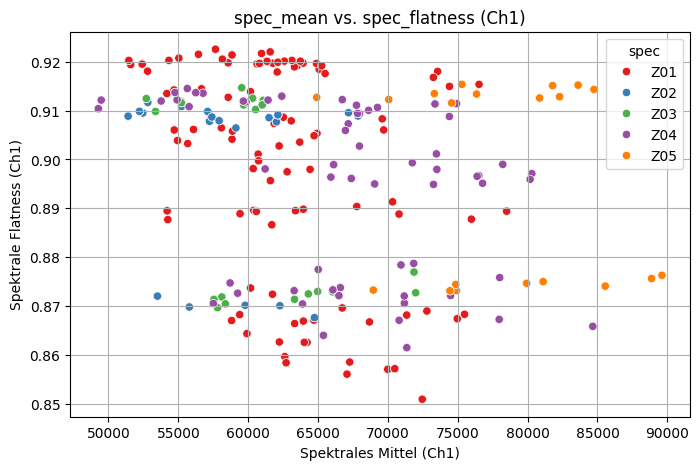

In [86]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_features,
    x='spec_mean_ch1', 
    y='spec_flatness_ch1', 
    hue='spec',  
    palette='Set1'
)
plt.title('spec_mean vs. spec_flatness (Ch1)')
plt.xlabel('Spektrales Mittel (Ch1)')
plt.ylabel('Spektrale Flatness (Ch1)')
plt.grid()
plt.show()

## 4.3 Histogram: distribution of a single characteristic

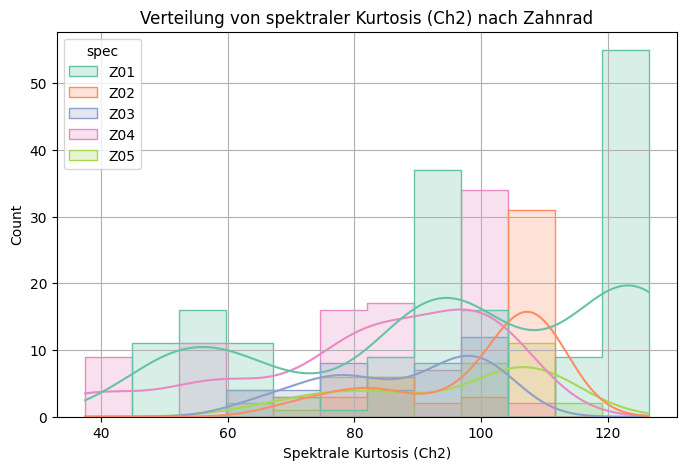

In [87]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_features, x='spec_kurtosis_ch2', hue='spec', kde=True, element='step', palette='Set2')
plt.title('Verteilung von spektraler Kurtosis (Ch2) nach Zahnrad')
plt.xlabel('Spektrale Kurtosis (Ch2)')
plt.grid()
plt.show()

## 4.4 Pairplot (Seaborn): clustering by characteristics

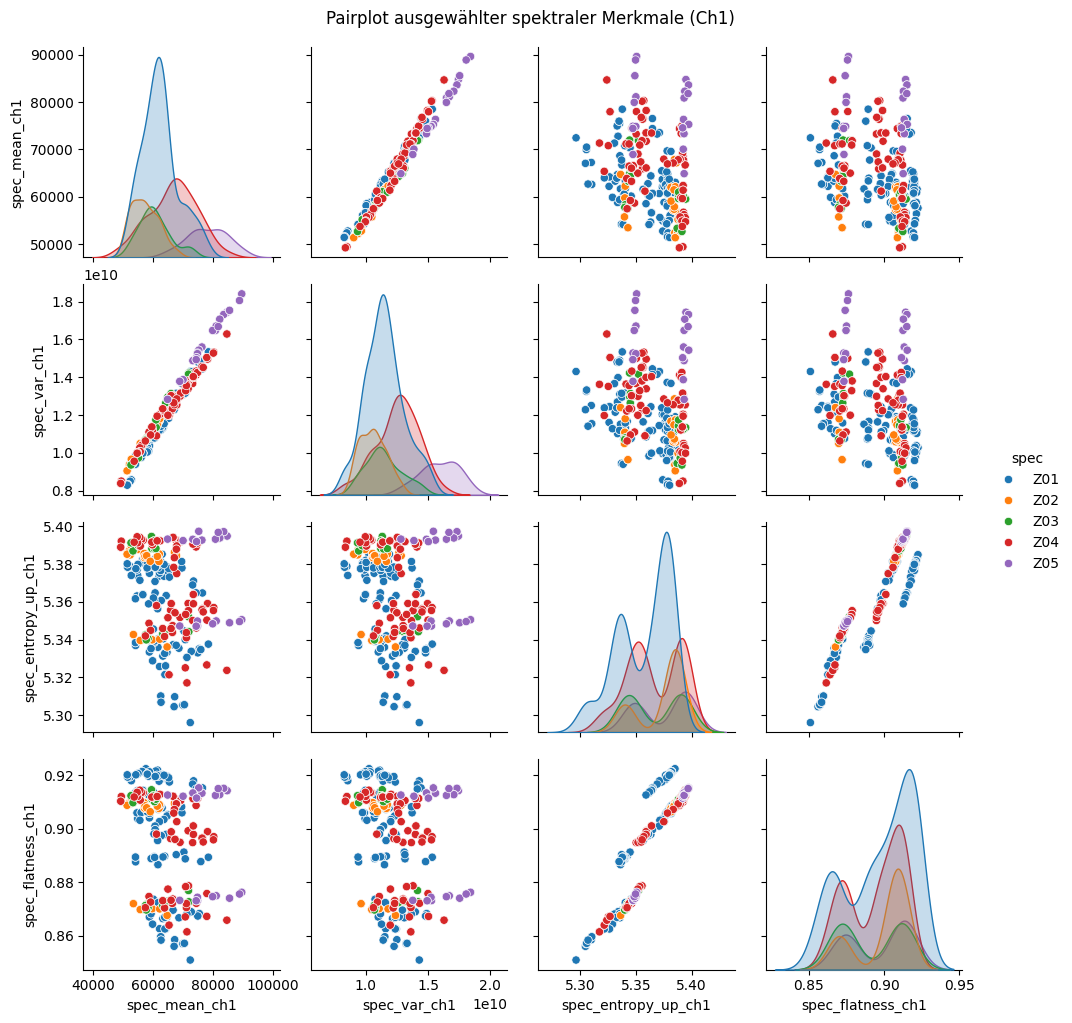

In [88]:
selected = ['spec_mean_ch1', 'spec_var_ch1', 'spec_entropy_up_ch1', 'spec_flatness_ch1']
sns.pairplot(df_features[selected + ['spec']], hue='spec', palette='tab10')
plt.suptitle('Pairplot ausgewählter spektraler Merkmale (Ch1)', y=1.02)
plt.show()

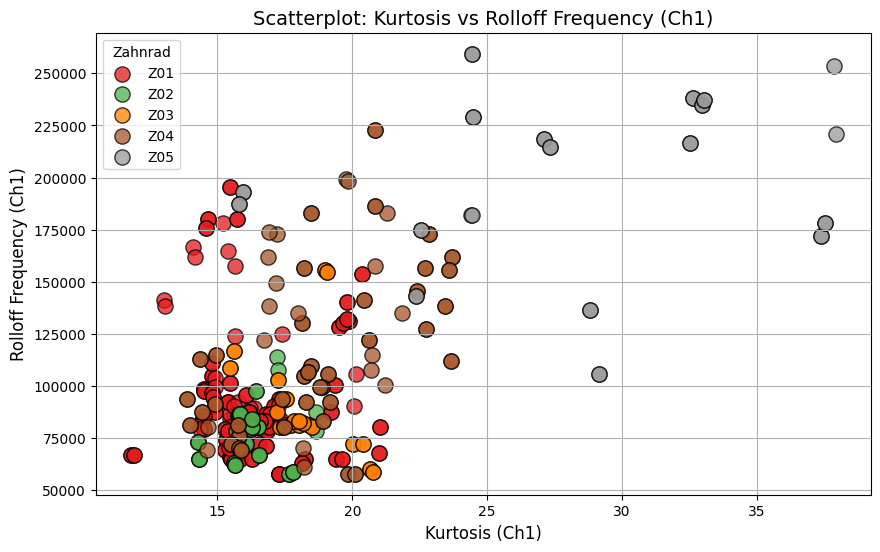

In [89]:
# Определяем цвета
colors = plt.cm.Set1(np.linspace(0, 1, 5))
spec_labels = sorted(df_ch1_features['spec'].unique())
color_map = {label: colors[i] for i, label in enumerate(spec_labels)}

# Строим scatter plot
plt.figure(figsize=(10, 6))
for label in spec_labels:
    mask = df_ch1_features['spec'] == label
    plt.scatter(
        df_ch1_features.loc[mask, 'sig_kurtosis_ch1'],
        df_ch1_features.loc[mask, 'spec_rolloff_freq_ch1'],
        label=label,
        c=color_map[label].reshape(1, -1),
        edgecolors='k',
        alpha=0.75,
        s=120
    )

plt.grid(True)
plt.title("Scatterplot: Kurtosis vs Rolloff Frequency (Ch1)", fontsize=14)
plt.xlabel("Kurtosis (Ch1)", fontsize=12)
plt.ylabel("Rolloff Frequency (Ch1)", fontsize=12)
plt.legend(title="Zahnrad", loc="best")
plt.show()


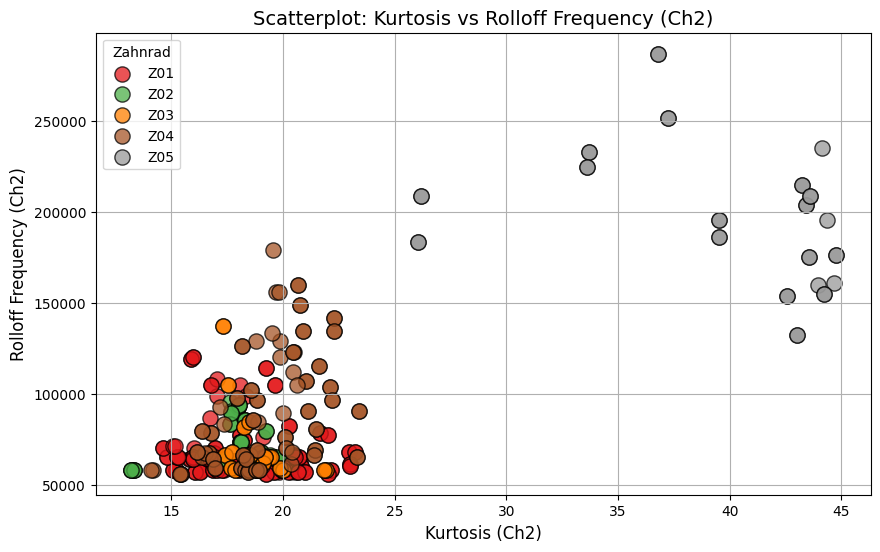

In [90]:
# Определяем цвета
colors = plt.cm.Set1(np.linspace(0, 1, 5))
spec_labels = sorted(df_ch2_features['spec'].unique())
color_map = {label: colors[i] for i, label in enumerate(spec_labels)}

# Строим scatter plot
plt.figure(figsize=(10, 6))
for label in spec_labels:
    mask = df_ch2_features['spec'] == label
    plt.scatter(
        df_ch2_features.loc[mask, 'sig_kurtosis_ch2'],
        df_ch2_features.loc[mask, 'spec_rolloff_freq_ch2'],
        label=label,
        c=color_map[label].reshape(1, -1),
        edgecolors='k',
        alpha=0.75,
        s=120
    )

plt.grid(True)
plt.title("Scatterplot: Kurtosis vs Rolloff Frequency (Ch2)", fontsize=14)
plt.xlabel("Kurtosis (Ch2)", fontsize=12)
plt.ylabel("Rolloff Frequency (Ch2)", fontsize=12)
plt.legend(title="Zahnrad", loc="best")
plt.show()


In [91]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm  # уже должен быть импортирован

def correlation_matrix(df, title="Feature Correlation Matrix"):
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111)

    # Новый способ получения colormap
    cmap = plt.colormaps.get_cmap('coolwarm')

    cax = ax.imshow(df.corr(), interpolation="nearest", cmap=cmap, vmin=-1, vmax=1)
    ax.grid(True)
    plt.title(title, fontsize=15)
    labels = df.columns
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    fig.colorbar(cax)
    plt.tight_layout()
    plt.show()


In [92]:
df_long = pd.DataFrame({
    'RMS': np.concatenate([df_ch1_features['sig_rms_ch1'], df_ch2_features['sig_rms_ch2']]),
    'Flatness': np.concatenate([df_ch1_features['spec_flatness_ch1'], df_ch2_features['spec_flatness_ch2']]),
    'Channel': ['Ch1'] * len(df_ch1_features) + ['Ch2'] * len(df_ch2_features)
})

C:\Users\kozyrev\AppData\Local\Temp\ipykernel_12640\607437565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Channel', y='RMS', data=df_long, palette='Set2')


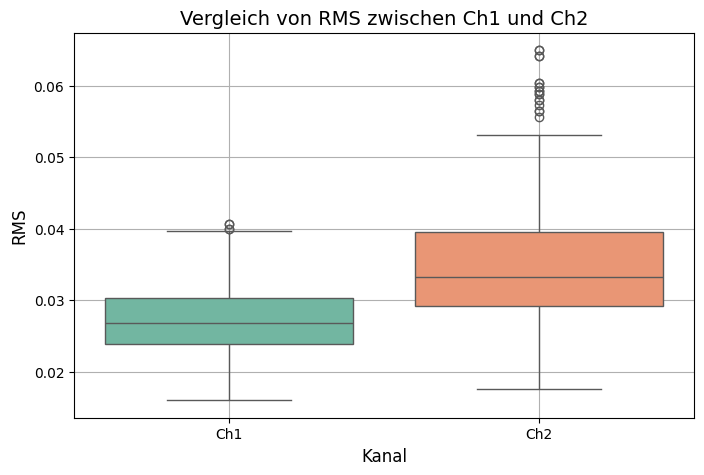

In [93]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Channel', y='RMS', data=df_long, palette='Set2')
plt.title('Vergleich von RMS zwischen Ch1 und Ch2', fontsize=14)
plt.ylabel('RMS', fontsize=12)
plt.xlabel('Kanal', fontsize=12)
plt.grid()
plt.show()

C:\Users\kozyrev\AppData\Local\Temp\ipykernel_12640\2147272270.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Channel', y='Flatness', data=df_long, palette='Set1')


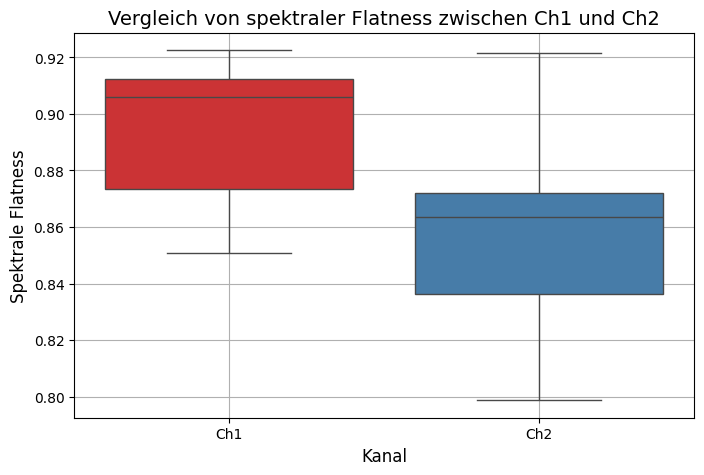

In [94]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Channel', y='Flatness', data=df_long, palette='Set1')
plt.title('Vergleich von spektraler Flatness zwischen Ch1 und Ch2', fontsize=14)
plt.ylabel('Spektrale Flatness', fontsize=12)
plt.xlabel('Kanal', fontsize=12)
plt.grid()
plt.show()

## 5. Unterteilen Sie die Z01–Z05-Daten in 3 Mengen (Train / Dev / Test)

In [95]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()



# # 1. Definiere Labels
# df_ch1_features = df_ch1_features.copy()
# df_ch1_features['label'] = df_ch1_features['spec'].apply(lambda x: 0 if x == 'Z05' else 1)

# # 2. Teile in Train/Dev/Test nach spec
# df_train_full = df_ch1_features[df_ch1_features['spec'].isin(['Z01', 'Z02', 'Z03', 'Z04'])].copy()
# df_test = df_ch1_features[df_ch1_features['spec'] == 'Z05'].copy()

# # 3. Split train_full in Train + Dev
# X_full = df_train_full.drop(columns=['spec', 'label'])
# y_full = df_train_full['label']

# X_train, X_dev, y_train, y_dev = train_test_split(X_full, y_full, test_size=0.25, random_state=42, stratify=y_full)

# # 4. Test-Set
# X_test = df_test.drop(columns=['spec', 'label'])
# y_test = df_test['label']

# print(f"Train: {X_train.shape[0]} Beispiele")
# print(f"Dev:   {X_dev.shape[0]} Beispiele")
# print(f"Test:  {X_test.shape[0]} Beispiele")

# X_train_scaled = scaler.fit_transform(X_train_clean)
# X_dev_scaled = scaler.transform(X_dev_clean)
# X_test_scaled = scaler.transform(X_test_clean)


# 🎯 Schritt: Aufteilung in Train / Dev / Test + Label hinzufügen

# 1 = gut, 0 = defekt (Z05)
df_ch1_features['label'] = df_ch1_features['spec'].apply(lambda x: 0 if x == 'Z05' else 1)

# Separate Datensätze nach spec
train_df = df_ch1_features[df_ch1_features['spec'].isin(['Z01', 'Z02', 'Z03'])].copy()
dev_df   = df_ch1_features[df_ch1_features['spec'] == 'Z04'].copy()
test_df  = df_ch1_features[df_ch1_features['spec'] == 'Z05'].copy()

# Ausgabe für Kontrolle
print(f"Train size: {train_df.shape}")
print(f"Dev size:   {dev_df.shape}")
print(f"Test size:  {test_df.shape}")
print("\nLabel-Verteilung (Train):")
print(train_df['label'].value_counts())



Train size: (256, 15)
Dev size:   (100, 15)
Test size:  (36, 15)

Label-Verteilung (Train):
label
1    256
Name: count, dtype: int64


## 6. Finden Sie den am besten geeigneten Ansatz zur Merkmalsanalyse

## 6.1 Feature Importance (Channel 1)

C:\Users\kozyrev\AppData\Local\Temp\ipykernel_12640\4205503990.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\kozyrev\PersonalCode\KIinMaterialdiagnostik\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


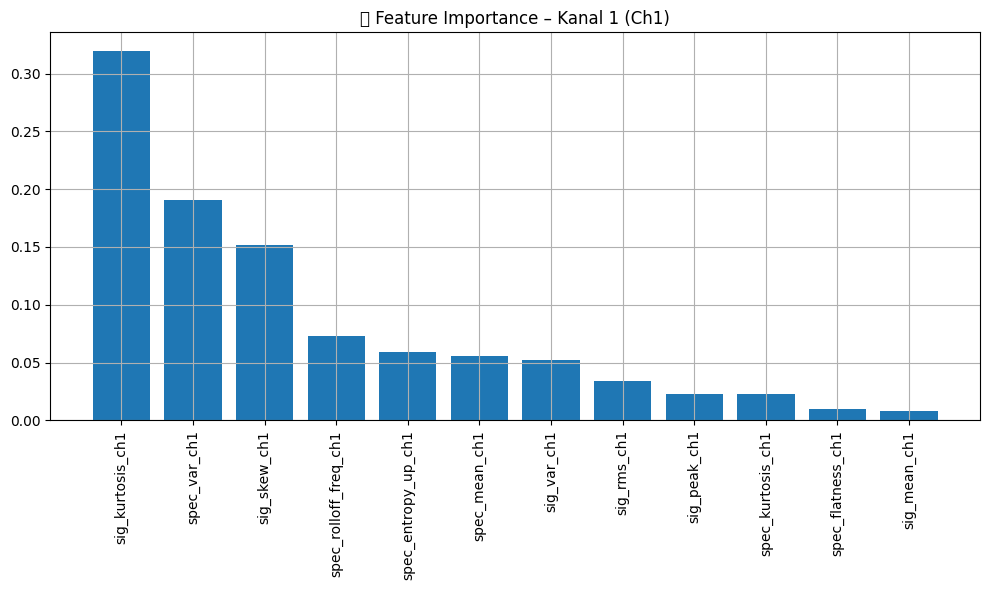

🔎 Top-3 Features Ch1: ['sig_kurtosis_ch1', 'spec_var_ch1', 'sig_skew_ch1']


In [96]:
from sklearn.ensemble import RandomForestClassifier

df_ch1 = df_ch1_features.copy()
df_ch1['label'] = df_ch1['spec'].apply(lambda x: 0 if x == 'Z05' else 1)

X_ch1 = df_ch1.drop(columns=['spec', 'label']).select_dtypes(include=[np.number])
y_ch1 = df_ch1['label']

rf_ch1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ch1.fit(X_ch1, y_ch1)

importances_ch1 = rf_ch1.feature_importances_
indices_ch1 = np.argsort(importances_ch1)[::-1]
top_features_ch1 = X_ch1.columns[indices_ch1]

plt.figure(figsize=(10,6))
plt.title("📊 Feature Importance – Kanal 1 (Ch1)")
plt.bar(range(len(importances_ch1)), importances_ch1[indices_ch1], align='center')
plt.xticks(range(len(importances_ch1)), top_features_ch1, rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

print("🔎 Top-3 Features Ch1:", top_features_ch1[:3].tolist())

## 6.2 Feature Importance (Channel 2)

C:\Users\kozyrev\AppData\Local\Temp\ipykernel_12640\4169825480.py:18: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\kozyrev\PersonalCode\KIinMaterialdiagnostik\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


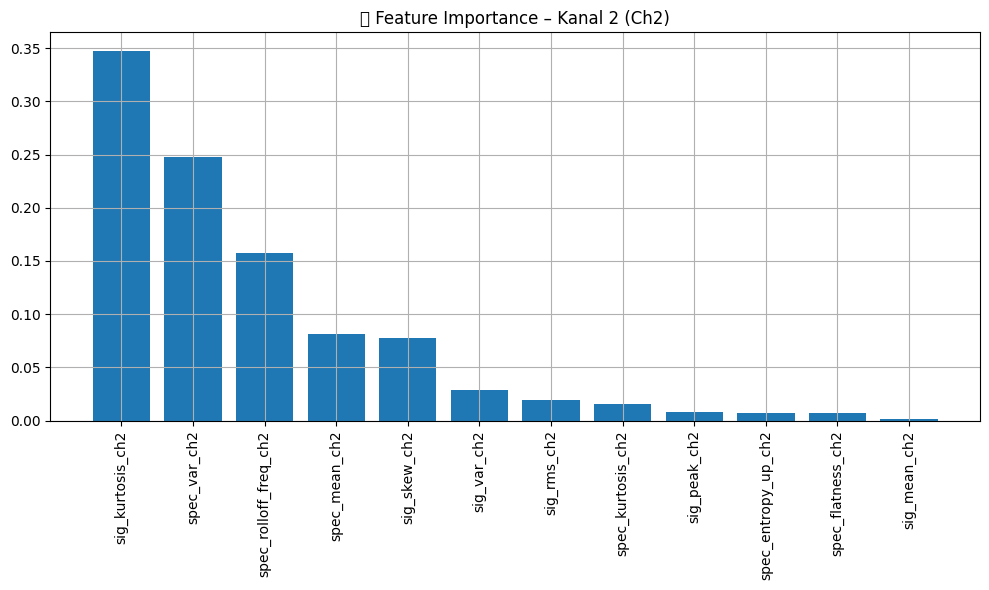

🔎 Top-3 Features Ch2: ['sig_kurtosis_ch2', 'spec_var_ch2', 'spec_rolloff_freq_ch2']


In [97]:
df_ch2 = df_ch2_features.copy()
df_ch2['label'] = df_ch2['spec'].apply(lambda x: 0 if x == 'Z05' else 1)

X_ch2 = df_ch2.drop(columns=['spec', 'label']).select_dtypes(include=[np.number])
y_ch2 = df_ch2['label']

rf_ch2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ch2.fit(X_ch2, y_ch2)

importances_ch2 = rf_ch2.feature_importances_
indices_ch2 = np.argsort(importances_ch2)[::-1]
top_features_ch2 = X_ch2.columns[indices_ch2]

plt.figure(figsize=(10,6))
plt.title("📊 Feature Importance – Kanal 2 (Ch2)")
plt.bar(range(len(importances_ch2)), importances_ch2[indices_ch2], align='center')
plt.xticks(range(len(importances_ch2)), top_features_ch2, rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

print("🔎 Top-3 Features Ch2:", top_features_ch2[:3].tolist())

## 7.Feature Scaling und Aufbereitung für Klassifikation (nur Kanal 1)

Wir verwenden StandardScaler von sklearn, und bereiten X_train, X_dev, X_test sowie y_train usw. vor.

In [98]:
from sklearn.preprocessing import StandardScaler

# Spalten, die Features enthalten (ohne 'spec', 'label', 'sig_ch1')
from sklearn.model_selection import train_test_split

# noise_level = 0.3 # 30% от амплитуды признаков



# Features und Labels
feature_cols = [c for c in df_ch1_features.columns if c.endswith('_ch1')]
X = df_ch1_features[feature_cols].select_dtypes(include=[np.number])
y = df_ch1_features['label']

# Erstes Split: 60 % Train, 40 % Temp (Dev+Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=0.6, stratify=y, random_state=42)

# Zweites Split des Temp-Sets für je 50/50 Dev und Test
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, train_size=0.5, stratify=y_temp, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

# X_train_noisy = X_train_scaled + noise_level * np.random.normal(loc=0.0, scale=1.0, size=X_train_scaled.shape)
# X_dev_noisy = X_dev_scaled + noise_level * np.random.normal(loc=0.0, scale=1.0, size=X_dev_scaled.shape)
# X_test_noisy = X_test_scaled + noise_level * np.random.normal(loc=0.0, scale=1.0, size=X_test_scaled.shape)

print("✅ Daten gesplittet und skaliert!")
print("Train labels:", np.bincount(y_train))
print("Dev labels: ", np.bincount(y_dev))
print("Test labels: ", np.bincount(y_test))



✅ Daten gesplittet und skaliert!
Train labels: [ 22 213]
Dev labels:  [ 7 71]
Test labels:  [ 7 72]


📊 Klassifikationsbericht:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.99      1.00      0.99        72

    accuracy                           0.99        79
   macro avg       0.99      0.93      0.96        79
weighted avg       0.99      0.99      0.99        79



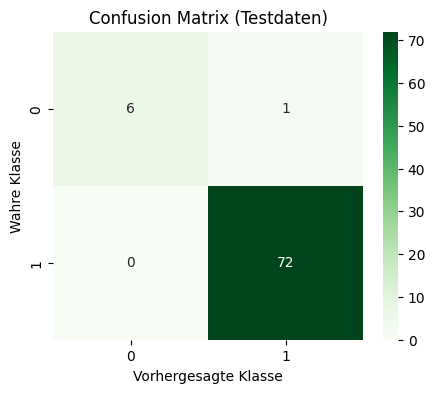

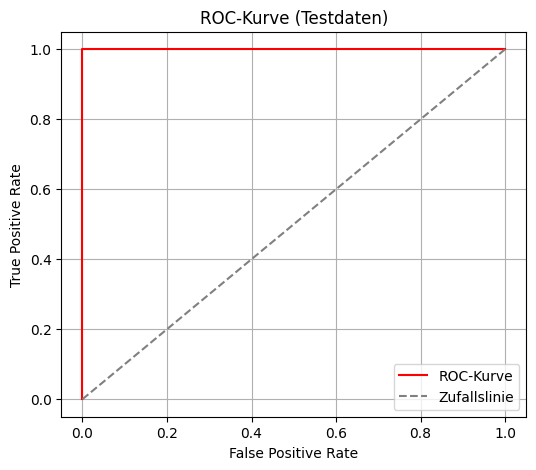

🎯 ROC-AUC Score: 1.000
Распределение классов в y_test: [ 7 72]
Train: [ 22 213]
Dev:   [ 7 71]


In [99]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns

# MLP initialize
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), # zwei versteckte Schichten
max_iter=500,
activation='relu',
solver='adam',
random_state=42)

mlp.fit(X_train_scaled, y_train)

y_pred = mlp.predict(X_test_scaled)
y_proba = mlp.predict_proba(X_test_scaled)[:, 1] # Wahrscheinlichkeit für Klasse 1 ("gut")

print("📊 Klassifikationsbericht:")
print(classification_report(y_test, y_pred))

conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (Testdaten)')
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Wahre Klasse')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label='ROC-Kurve', color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Zufallslinie')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Kurve (Testdaten)')
plt.legend()
plt.grid(True)
plt.show()
auc_score = roc_auc_score(y_test, y_proba)
print(f"🎯 ROC-AUC Score: {auc_score:.3f}")
print("Распределение классов в y_test:", np.bincount(y_test))
print("Train:", np.bincount(y_train))
print("Dev:  ", np.bincount(y_dev))


## 8. Training von Modell beim Benutzen der 3 wichtigsten Merkmalen


## 8.1 Channel 1

📊 Klassifikationsbericht:
              precision    recall  f1-score   support

           0       1.00      0.57      0.73         7
           1       0.96      1.00      0.98        72

    accuracy                           0.96        79
   macro avg       0.98      0.79      0.85        79
weighted avg       0.96      0.96      0.96        79



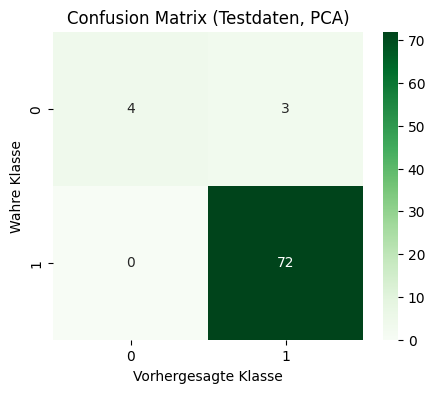

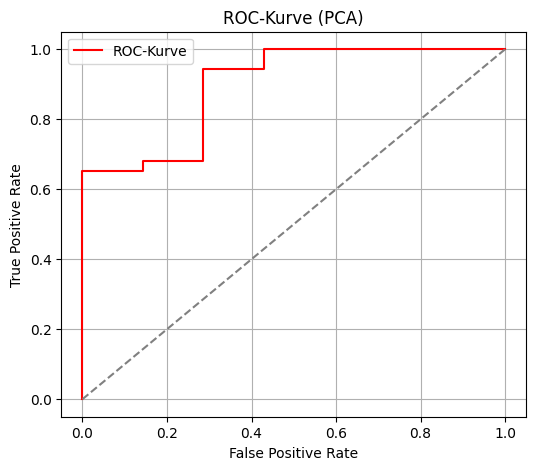

🎯 ROC-AUC Score (PCA): 0.897


In [100]:
top3_features = ['spec_kurtosis_ch1', 'spec_var_ch1', 'spec_mean_ch1']

X = df_ch1_features[top3_features]
y = df_ch1_features['label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.6, stratify=y, random_state=42)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, train_size=0.5, stratify=y_temp, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_dev_pca = pca.transform(X_dev_scaled)
X_test_pca = pca.transform(X_test_scaled)

mlp = MLPClassifier(hidden_layer_sizes=(32,), max_iter=500, activation='relu', solver='adam', random_state=42)
mlp.fit(X_train_pca, y_train)

y_pred = mlp.predict(X_test_pca)
y_proba = mlp.predict_proba(X_test_pca)[:, 1]

print("📊 Klassifikationsbericht:")
print(classification_report(y_test, y_pred))

conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (Testdaten, PCA)')
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Wahre Klasse')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label='ROC-Kurve', color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Kurve (PCA)')
plt.grid(True)
plt.legend()
plt.show()

auc_score = roc_auc_score(y_test, y_proba)
print(f"🎯 ROC-AUC Score (PCA): {auc_score:.3f}")



## 8.2 Channel 2

Index(['sig_kurtosis_ch2', 'spec_var_ch2', 'spec_rolloff_freq_ch2'], dtype='object')
📊 Klassifikationsbericht:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        72

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



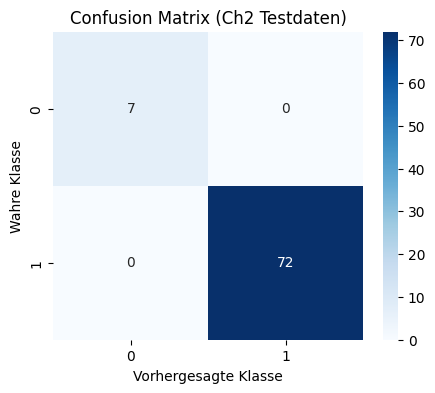

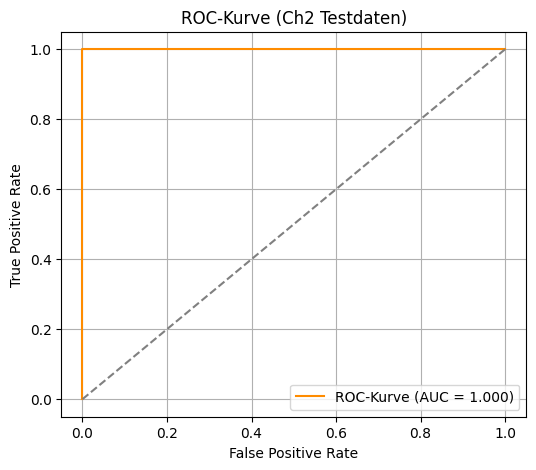

🎯 ROC-AUC Score (Ch2): 1.000
Распределение классов:
Train: [ 22 213]
Dev:  [ 7 71]
Test:  [ 7 72]


In [101]:
top_features_ch2 = top_features_ch2[:3]
print(top_features_ch2[:3])

# prepare Data for CH2
df_ch2 = df_ch2_features.copy()
df_ch2['label'] = df_ch2['spec'].apply(lambda x: 0 if x == 'Z05' else 1)
X = df_ch2[top_features_ch2]
y = df_ch2['label']

# split train / dev / test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.6, stratify=y, random_state=42)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, train_size=0.5, stratify=y_temp, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

# Train MLP
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, activation='relu', solver='adam', random_state=42)
mlp.fit(X_train_scaled, y_train)

y_pred = mlp.predict(X_test_scaled)
y_proba = mlp.predict_proba(X_test_scaled)[:, 1]

print("📊 Klassifikationsbericht:")
print(classification_report(y_test, y_pred))

conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Ch2 Testdaten)')
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Wahre Klasse')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC-Kurve (AUC = {auc_score:.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Kurve (Ch2 Testdaten)')
plt.legend()
plt.grid(True)
plt.show()

print(f"🎯 ROC-AUC Score (Ch2): {auc_score:.3f}")
print("Распределение классов:")
print("Train:", np.bincount(y_train))
print("Dev: ", np.bincount(y_dev))
print("Test: ", np.bincount(y_test))
